#  Part-1 Data Understanding & Loading

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sqlite3
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

#### Load Dataset csv

In [117]:
riders = pd.read_csv("riders.csv")
riders.head()

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,1,Anjali Patel,56.0,Male,Delhi,2021-06-15,156,44.0,3.55
1,2,Priya Gupta,46.0,NaN,Delhi,2023-03-23,492,14.0,2.52
2,3,Vikas Mehta,32.0,Female,Chennai,2021-01-17,70,19.0,4.64
3,4,Pooja Gupta,25.0,Female,Delhi,2022-12-27,169,28.0,NaN
4,5,Sneha Mehta,38.0,Male,Chennai,2022-06-02,272,41.0,4.87


#### Load Dataset json

In [118]:
trips = pd.read_json("trips.json")
trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,1,103,Central,22.48,45,517.74,Card,2023-05-12T00:40:00.000,0
1,2,436,Central,14.14,43,536.38,Card,2023-03-12T02:43:00.000,0
2,3,861,North,20.62,17,250.55,UPI,2023-04-29T23:49:00.000,0
3,4,271,North,11.86,68,61.33,Card,2023-01-22T21:51:00.000,1
4,5,107,South,16.45,15,773.76,UPI,2023-03-04T08:53:00.000,1


In [119]:
trips.columns

Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'payment_mode', 'ride_date', 'surge_flag'],
      dtype='str')

#### Load Dataset SQL

In [120]:
# Load SQL
conn = sqlite3.connect(":memory:")

with open("city_zones.sql", "r") as f:
    sql_script = f.read()

conn.executescript(sql_script)

zones = pd.read_sql("SELECT * FROM city_zones", conn)

In [121]:
zones.head()

,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,West,20915,1.98,55.58,Residential
1,Central,40915,6.85,55.95,Mixed
2,East,38219,7.89,41.21,Mixed
3,Central,16343,9.33,47.51,Mixed
4,Central,47403,4.94,NaN,Mixed


In [122]:
# import mysql.connector

# conn = mysql.connector.connect(
#     host="localhost",
#     user="root",
#     password="498910",
#     database="city_zones"
# )
# sql_query = "SELECT * FROM city_zones"
# zones = pd.read_sql(sql_query, conn)

# print("Data loaded successfully from mySQL database.")
# zones.head()

### Dataset Information

In [123]:
riders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         1000 non-null   int64  
 1   name             1000 non-null   str    
 2   age              927 non-null    float64
 3   gender           879 non-null    str    
 4   city             912 non-null    str    
 5   signup_date      1000 non-null   str    
 6   total_rides      1000 non-null   int64  
 7   cancelled_rides  966 non-null    float64
 8   avg_rating       945 non-null    float64
dtypes: float64(3), int64(2), str(4)
memory usage: 70.4 KB


In [124]:
trips.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       1000 non-null   int64  
 1   rider_id      1000 non-null   int64  
 2   zone          962 non-null    str    
 3   distance_km   909 non-null    float64
 4   duration_min  1000 non-null   int64  
 5   fare_amount   853 non-null    float64
 6   payment_mode  937 non-null    str    
 7   ride_date     1000 non-null   str    
 8   surge_flag    1000 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 70.4 KB


In [125]:
zones.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zone_name           1000 non-null   str    
 1   population_density  1000 non-null   int64  
 2   traffic_index       923 non-null    float64
 3   avg_speed_kmph      877 non-null    float64
 4   zone_type           951 non-null    str    
dtypes: float64(2), int64(1), str(2)
memory usage: 39.2 KB


In [126]:
riders.columns

Index(['rider_id', 'name', 'age', 'gender', 'city', 'signup_date',
       'total_rides', 'cancelled_rides', 'avg_rating'],
      dtype='str')

In [127]:
print("Riders Shape:", riders.shape)
print("Trips Shape:", trips.shape)
print("Zones Shape:", zones.shape)

Riders Shape: (1000, 9)
Trips Shape: (1000, 9)
Zones Shape: (1000, 5)


#### Check Missing Value

In [128]:
print(riders.isnull().sum())

rider_id             0
name                 0
age                 73
gender             121
city                88
signup_date          0
total_rides          0
cancelled_rides     34
avg_rating          55
dtype: int64


In [129]:
print(trips.isnull().sum())

trip_id           0
rider_id          0
zone             38
distance_km      91
duration_min      0
fare_amount     147
payment_mode     63
ride_date         0
surge_flag        0
dtype: int64


In [130]:
print(zones.isnull().sum())

zone_name               0
population_density      0
traffic_index          77
avg_speed_kmph        123
zone_type              49
dtype: int64


### Check Missing value on visualization

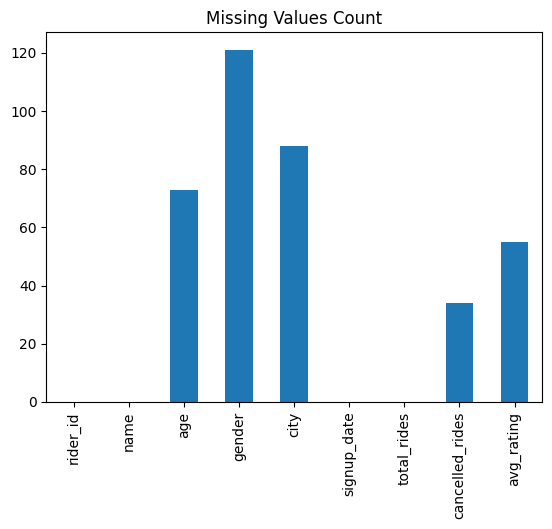

In [131]:
riders.isnull().sum().plot(kind='bar')
plt.title("Missing Values Count")
plt.show()

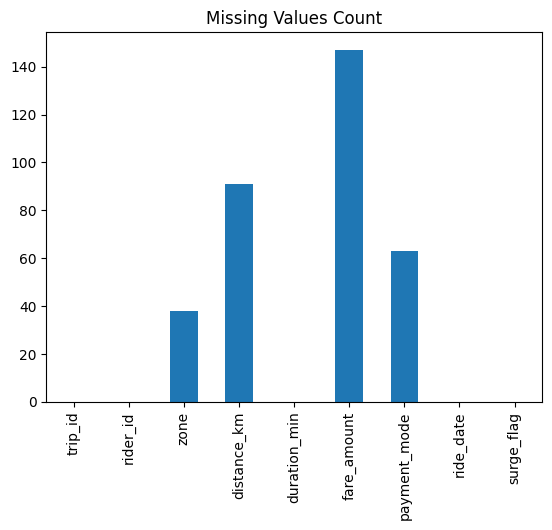

In [132]:
trips.isnull().sum().plot(kind='bar')
plt.title("Missing Values Count")
plt.show()

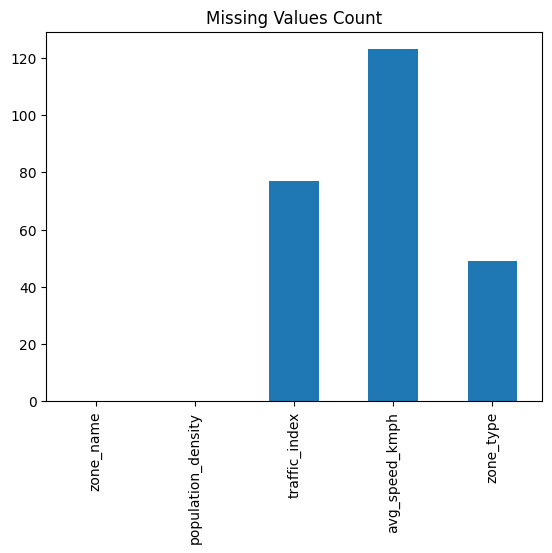

In [133]:
zones.isnull().sum().plot(kind='bar')
plt.title("Missing Values Count")
plt.show()

### Drop Duplicate Value 

In [134]:
riders.drop_duplicates(inplace=True)

In [135]:
trips.drop_duplicates(inplace=True)

In [136]:
zones.drop_duplicates(inplace=True)

# Part-2 Data Cleaning

#### Fill Numerical Column on Trips(Json)

In [137]:
num_cols_trips = trips.select_dtypes(include=np.number).columns

imputer_mean = SimpleImputer(strategy="mean")
trips[num_cols_trips] = imputer_mean.fit_transform(trips[num_cols_trips])

In [138]:
trips[num_cols_trips]

,trip_id,rider_id,distance_km,duration_min,fare_amount,surge_flag
0,1.0,103.0,22.48000,45.0,517.740000,0.0
1,2.0,436.0,14.14000,43.0,536.380000,0.0
2,3.0,861.0,20.62000,17.0,250.550000,0.0
3,4.0,271.0,11.86000,68.0,61.330000,1.0
4,5.0,107.0,16.45000,15.0,773.760000,1.0
...,...,...,...,...,...,...
995,996.0,10.0,3.09000,24.0,484.581079,1.0
996,997.0,824.0,14.99703,45.0,793.970000,0.0
997,998.0,798.0,3.73000,58.0,270.550000,1.0
998,999.0,242.0,9.29000,24.0,207.740000,0.0


#### Fill Categorical Column On Trips(Json)

In [139]:
cat_cols_trips = trips.select_dtypes(include="object").columns

imputer_mode = SimpleImputer(strategy="most_frequent")
trips[cat_cols_trips] = imputer_mode.fit_transform(trips[cat_cols_trips])

C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_8916\1451199979.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_trips = trips.select_dtypes(include="object").columns


In [140]:
trips[cat_cols_trips]

,zone,payment_mode,ride_date
0,Central,Card,2023-05-12T00:40:00.000
1,Central,Card,2023-03-12T02:43:00.000
2,North,UPI,2023-04-29T23:49:00.000
3,North,Card,2023-01-22T21:51:00.000
4,South,UPI,2023-03-04T08:53:00.000
...,...,...,...
995,South,Cash,2023-05-06T19:03:00.000
996,West,Cash,2023-03-25T16:27:00.000
997,West,Card,2023-01-25T04:12:00.000
998,East,Cash,2023-02-04T10:10:00.000


##### Verify Missing Value trips

In [141]:
trips.isnull().sum()

trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

### Fill Numerical Column on Riders(csv)

In [142]:
num_cols_riders = riders.select_dtypes(include=np.number).columns
riders[num_cols_riders] = SimpleImputer(strategy="mean").fit_transform(riders[num_cols_riders])

In [143]:
riders[num_cols_riders]

,rider_id,age,total_rides,cancelled_rides,avg_rating
0,1.0,56.0,156.0,44.0,3.550000
1,2.0,46.0,492.0,14.0,2.520000
2,3.0,32.0,70.0,19.0,4.640000
3,4.0,25.0,169.0,28.0,3.736042
4,5.0,38.0,272.0,41.0,4.870000
...,...,...,...,...,...
995,996.0,41.0,49.0,1.0,3.960000
996,997.0,32.0,173.0,11.0,3.660000
997,998.0,46.0,82.0,41.0,4.050000
998,999.0,25.0,322.0,17.0,3.700000


### Fill Categorical Column on Riders(csv)

In [144]:
cat_cols_riders = riders.select_dtypes(include="object").columns
riders[cat_cols_riders] = SimpleImputer(strategy="most_frequent").fit_transform(riders[cat_cols_riders])

C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_8916\3672727617.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_riders = riders.select_dtypes(include="object").columns


In [145]:
riders[cat_cols_riders]

,name,gender,city,signup_date
0,Anjali Patel,Male,Delhi,2021-06-15
1,Priya Gupta,Male,Delhi,2023-03-23
2,Vikas Mehta,Female,Chennai,2021-01-17
3,Pooja Gupta,Female,Delhi,2022-12-27
4,Sneha Mehta,Male,Chennai,2022-06-02
...,...,...,...,...
995,Rahul Reddy,Female,Mumbai,2023-03-30
996,Anjali Yadav,Male,Bangalore,2020-11-26
997,Amit Yadav,Female,Mumbai,2020-11-28
998,Amit Kumar,Male,Delhi,2020-02-19


#### Verify Missing Value rider

In [146]:
riders.isnull().sum()

rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64

### Fill Numerical Column on Zones(Sql)

In [147]:
num_cols = ["traffic_index", "avg_speed_kmph"]
cat_cols = ["zone_type"]

num_imputer = SimpleImputer(strategy="median")
zones[num_cols] = num_imputer.fit_transform(zones[num_cols])

In [148]:
zones[num_cols]

,traffic_index,avg_speed_kmph
0,1.98,55.58
1,6.85,55.95
2,7.89,41.21
3,9.33,47.51
4,4.94,52.55
...,...,...
995,5.57,54.78
996,8.67,47.17
997,7.40,76.92
998,9.16,23.64


### Fill Categorical Column on Zones(Sql)

In [149]:
cat_imputer = SimpleImputer(strategy="most_frequent")
zones[cat_cols] = cat_imputer.fit_transform(zones[cat_cols])

#### Verify Missing value  zones

In [150]:
zones.isnull().sum()

zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64



# Part-3. Outlier Handling

## Check Outlier in Zones SQL

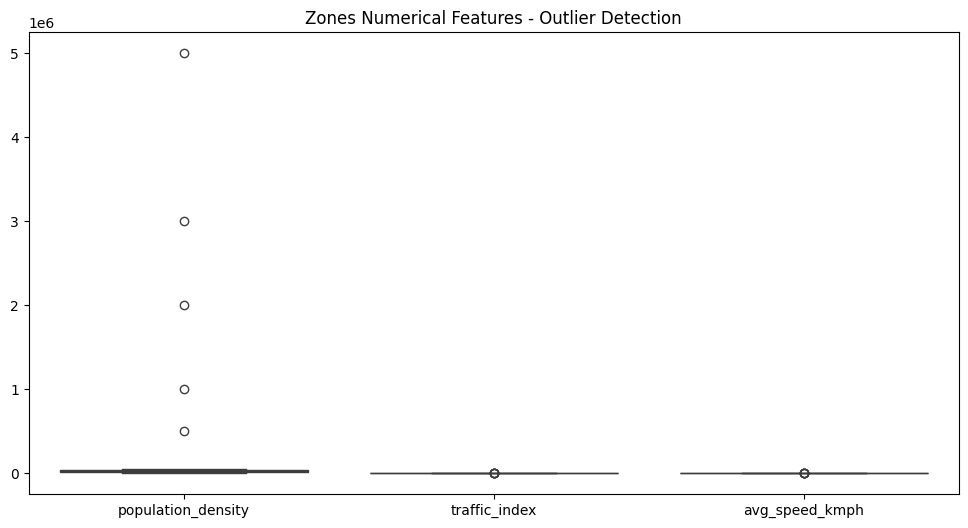

In [151]:
plt.figure(figsize=(12,6))

zones_numeric = zones[["population_density","traffic_index","avg_speed_kmph"]]

sns.boxplot(data=zones_numeric)

plt.title("Zones Numerical Features - Outlier Detection")
plt.show()

### Apply z-score

In [152]:
num_cols = ["population_density","traffic_index","avg_speed_kmph"]

In [153]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(zones[num_cols]))

# Threshold 3
zones_z = zones[(z_scores < 3).all(axis=1)]

print("Original Shape:", zones.shape)
print("After Z-score:", zones_z.shape)

Original Shape: (1000, 5)
After Z-score: (986, 5)


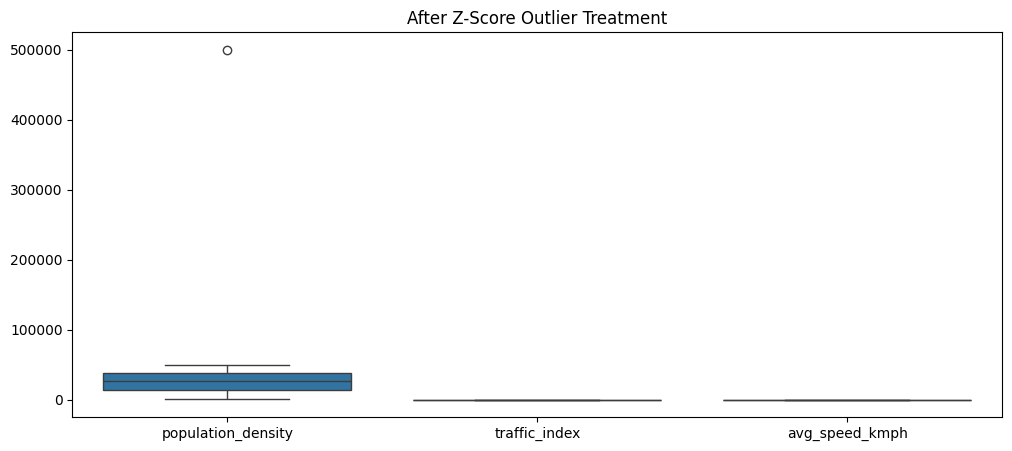

In [154]:
plt.figure(figsize=(12,5))
sns.boxplot(data=zones_z[num_cols])
plt.title("After Z-Score Outlier Treatment")
plt.show()

### Apply IQR

In [155]:
zones_iqr = zones.copy()

for col in num_cols:
    Q1 = zones[col].quantile(0.25)
    Q3 = zones[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    zones_iqr = zones_iqr[(zones_iqr[col] >= lower) & (zones_iqr[col] <= upper)]

print("After IQR:", zones_iqr.shape)

After IQR: (985, 5)


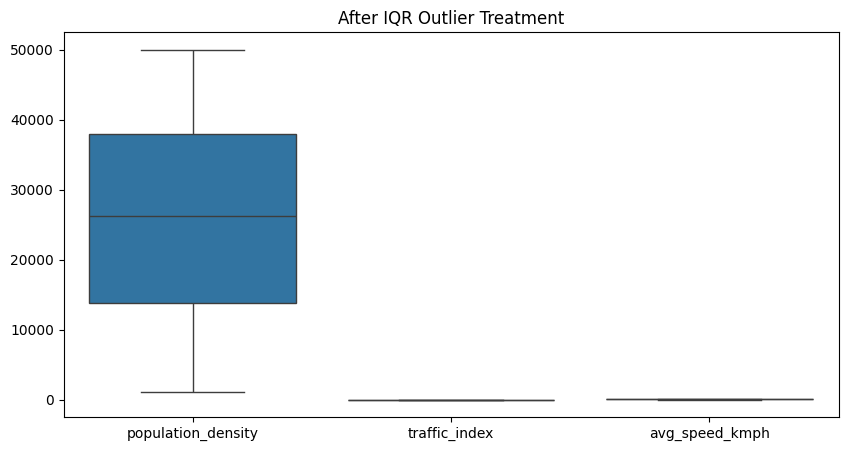

In [156]:
plt.figure(figsize=(10,5))
sns.boxplot(data=zones_iqr[num_cols])
plt.title("After IQR Outlier Treatment")
plt.show()

### Apply Winsorization

In [157]:
zones_win = zones.copy()

for col in num_cols:
    zones_win[col] = winsorize(zones[col], limits=[0.05, 0.05])

print("Winsorization Done")

Winsorization Done


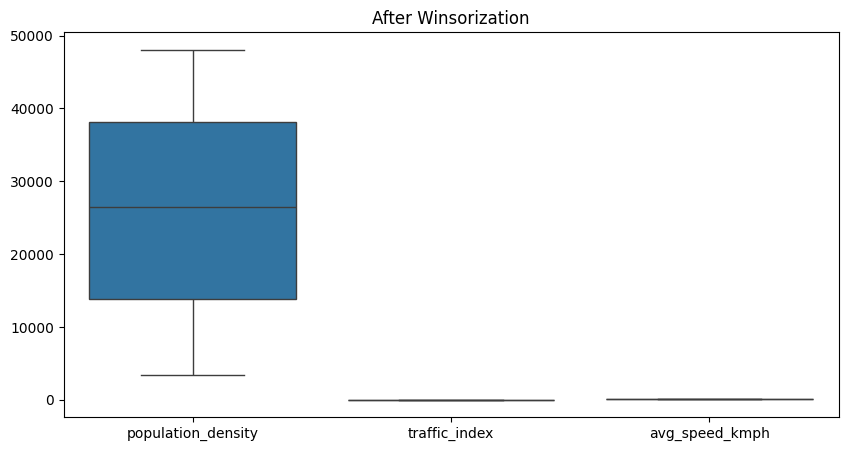

In [158]:
plt.figure(figsize=(10,5))
sns.boxplot(data=zones_win[num_cols])
plt.title("After Winsorization")
plt.show()

## BEFORE vs AFTER Comparison

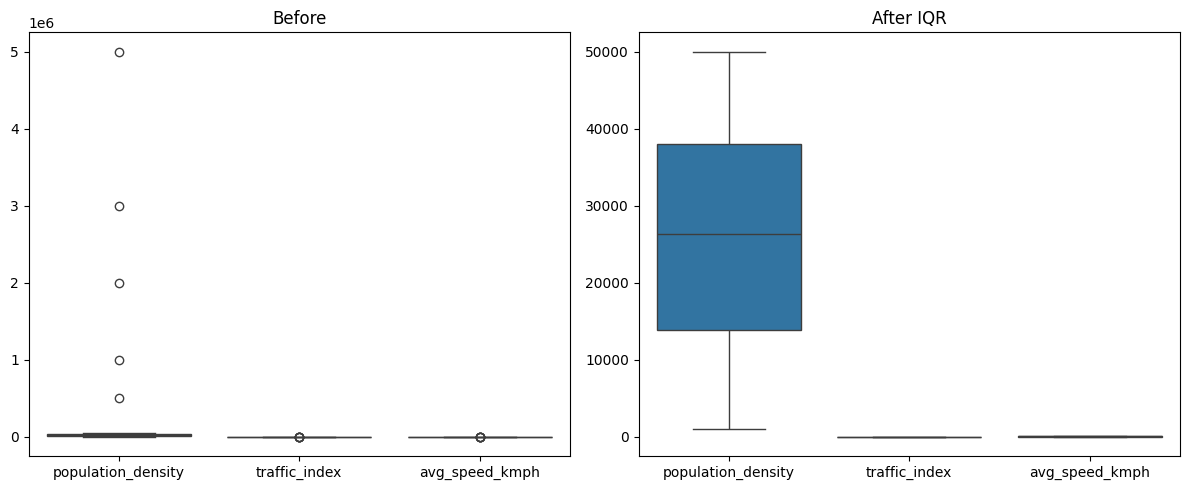

In [159]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=zones[num_cols])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(data=zones_iqr[num_cols])
plt.title("After IQR")

plt.tight_layout()
plt.show()

## Trips Before Outlier Removal (Visualization)

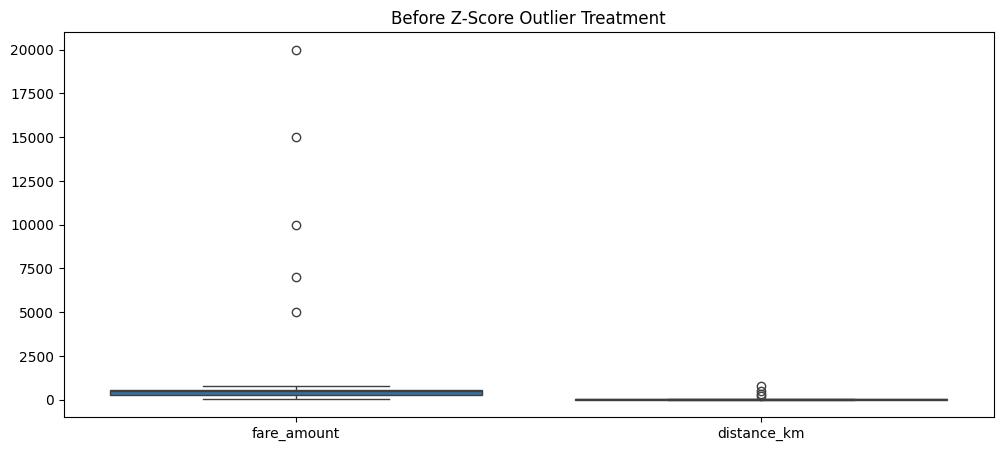

In [160]:
plt.figure(figsize=(12,5))
sns.boxplot(data=trips[["fare_amount","distance_km"]])
plt.title("Before Z-Score Outlier Treatment")
plt.show()

### Apply Z-Score

In [161]:
# Calculate Z-score
trips["fare_z"] = zscore(trips["fare_amount"])
trips["distance_z"] = zscore(trips["distance_km"])

# Define threshold
threshold = 3

# Remove outliers
trips_z_clean = trips[(abs(trips["fare_z"]) < threshold) & 
                      (abs(trips["distance_z"]) < threshold)]

trips_z_clean = trips_z_clean.drop(["fare_z","distance_z"], axis=1)

print("Original Shape:", trips.shape)
print("After Z-Score Shape:", trips_z_clean.shape)

Original Shape: (1000, 11)
After Z-Score Shape: (991, 9)


#### After Z-Score Removal

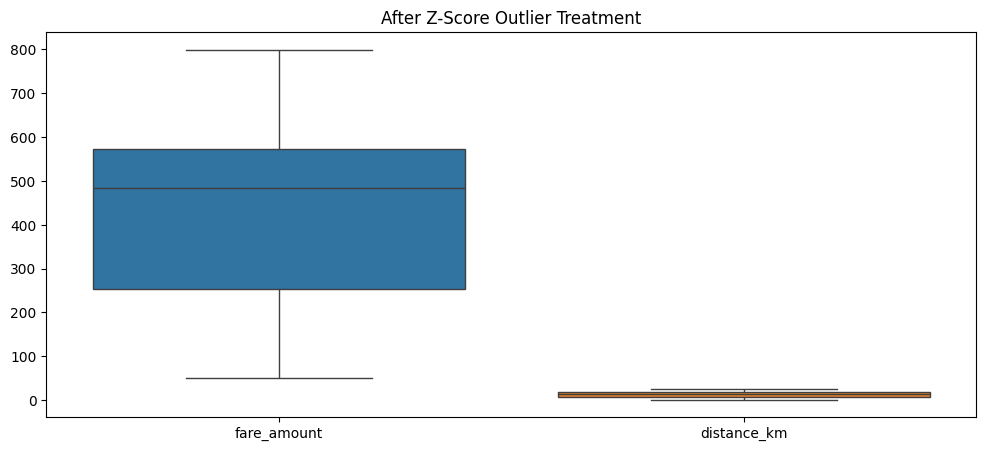

In [162]:
plt.figure(figsize=(12,5))
sns.boxplot(data=trips_z_clean[["fare_amount","distance_km"]])
plt.title("After Z-Score Outlier Treatment")
plt.show()

#### Before IQR

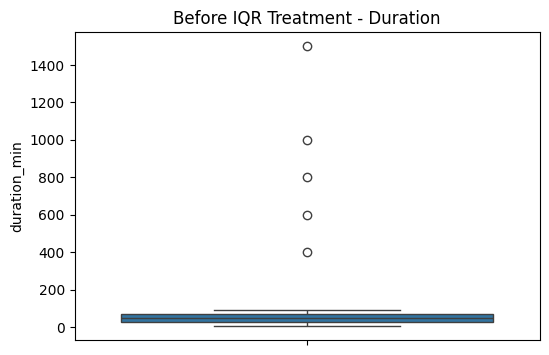

In [163]:
plt.figure(figsize=(6,4))
sns.boxplot(trips_z_clean["duration_min"])
plt.title("Before IQR Treatment - Duration")
plt.show()

#### Apply IQR

In [164]:
Q1 = trips_z_clean["duration_min"].quantile(0.25)
Q3 = trips_z_clean["duration_min"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

trips_iqr_clean = trips_z_clean[(trips_z_clean["duration_min"] >= lower) &
                                (trips_z_clean["duration_min"] <= upper)]

print("After IQR Shape:", trips_iqr_clean.shape)

After IQR Shape: (986, 9)


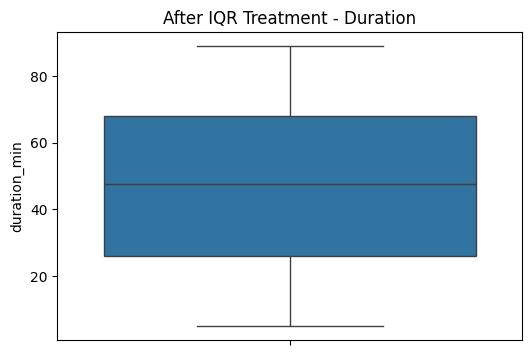

In [165]:
plt.figure(figsize=(6,4))
sns.boxplot(trips_iqr_clean["duration_min"])
plt.title("After IQR Treatment - Duration")
plt.show()

#### Before Winsorization

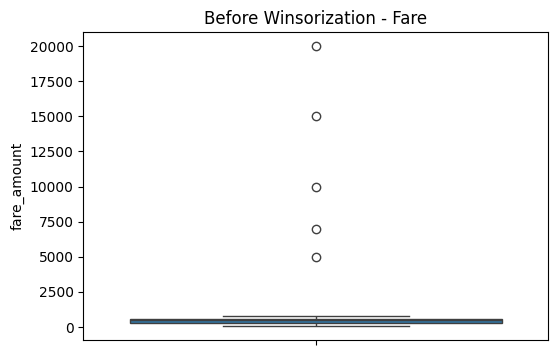

In [166]:
plt.figure(figsize=(6,4))
sns.boxplot(trips["fare_amount"])
plt.title("Before Winsorization - Fare")
plt.show()

#### Apply Winsorization

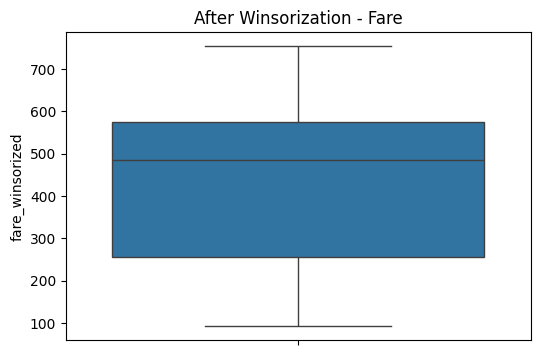

In [167]:
# 5% lower & upper capping
trips["fare_winsorized"] = winsorize(trips["fare_amount"], limits=[0.05, 0.05])

plt.figure(figsize=(6,4))
sns.boxplot(trips["fare_winsorized"])
plt.title("After Winsorization - Fare")
plt.show()

### FINAL BEFORE vs AFTER COMPARISON

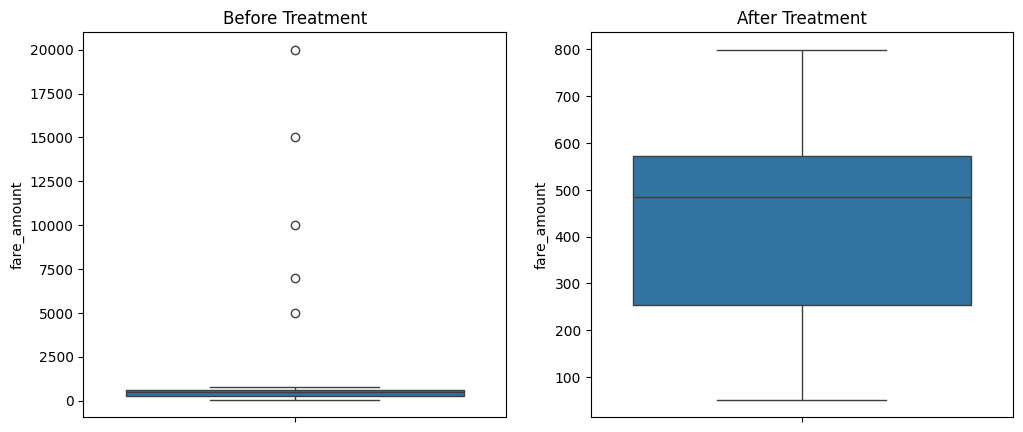

In [168]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(trips["fare_amount"], ax=axes[0])
axes[0].set_title("Before Treatment")

sns.boxplot(trips_iqr_clean["fare_amount"], ax=axes[1])
axes[1].set_title("After Treatment")

plt.show()

## Riders Before Outlier Handling(Visualization) 

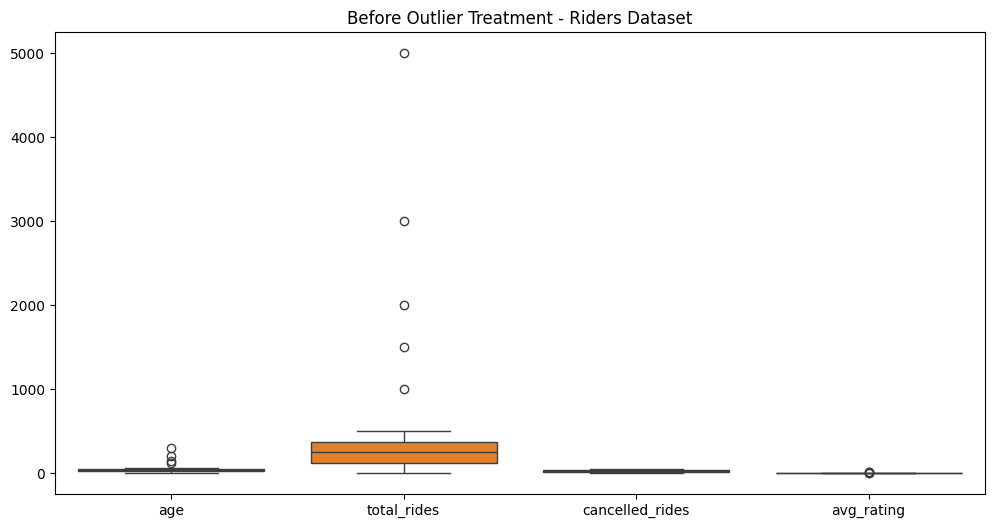

In [169]:
plt.figure(figsize=(12,6))
sns.boxplot(data=riders[["age","total_rides","cancelled_rides","avg_rating"]])
plt.title("Before Outlier Treatment - Riders Dataset")
plt.show()

#### Z-SCORE (total_rides, cancelled_rides)

In [170]:
riders["total_rides_z"] = zscore(riders["total_rides"])
riders["cancelled_rides_z"] = zscore(riders["cancelled_rides"])

threshold = 3

riders_z_clean = riders[
    (abs(riders["total_rides_z"]) < threshold) &
    (abs(riders["cancelled_rides_z"]) < threshold)
]

riders_z_clean = riders_z_clean.drop(["total_rides_z","cancelled_rides_z"], axis=1)

print("Original Shape:", riders.shape)
print("After Z-Score Shape:", riders_z_clean.shape)

Original Shape: (1000, 11)
After Z-Score Shape: (995, 9)


#### IQR METHOD (Age)

In [171]:
Q1 = riders_z_clean["age"].quantile(0.25)
Q3 = riders_z_clean["age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

riders_iqr_clean = riders_z_clean[
    (riders_z_clean["age"] >= lower) &
    (riders_z_clean["age"] <= upper)
]

print("After IQR Shape:", riders_iqr_clean.shape)

After IQR Shape: (991, 9)


#### WINSORIZATION (avg_rating)

In [172]:
riders_iqr_clean["avg_rating_winsorized"] = winsorize(
    riders_iqr_clean["avg_rating"],
    limits=[0.05, 0.05]
)

#### After Treatment Visualization

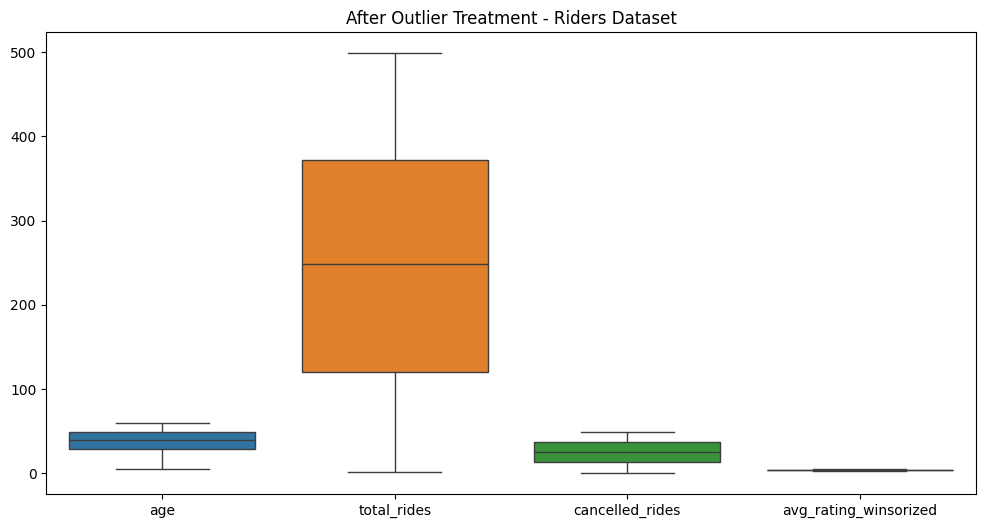

In [173]:
plt.figure(figsize=(12,6))
sns.boxplot(data=riders_iqr_clean[["age","total_rides","cancelled_rides","avg_rating_winsorized"]])
plt.title("After Outlier Treatment - Riders Dataset")
plt.show()

##### BEFORE vs AFTER COMPARISON (Single Graph)

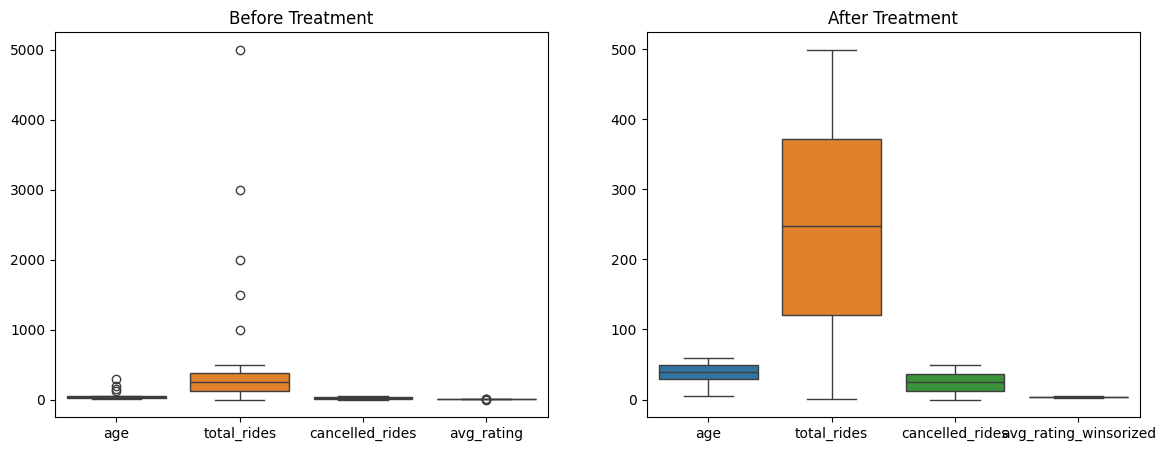

In [174]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(data=riders[["age","total_rides","cancelled_rides","avg_rating"]], ax=axes[0])
axes[0].set_title("Before Treatment")

sns.boxplot(data=riders_iqr_clean[["age","total_rides","cancelled_rides","avg_rating_winsorized"]], ax=axes[1])
axes[1].set_title("After Treatment")

plt.show()

# Part-4 Data Transformation

### TRIPS Dataset Transformation

####  1. Datetime Conversion

In [175]:
trips["ride_date"] = pd.to_datetime(trips["ride_date"])

trips["hour"] = trips["ride_date"].dt.hour
trips["day_of_week"] = trips["ride_date"].dt.dayofweek
trips["month"] = trips["ride_date"].dt.month

#### 2. One-Hot Encode

In [176]:
trips = pd.get_dummies(trips, columns=["payment_mode"], drop_first=True)

#### 3. Log Transform

In [177]:
trips["fare_log"] = np.log1p(trips["fare_amount"])
trips["distance_log"] = np.log1p(trips["distance_km"])

#### 4. Square Root Transform

In [178]:
trips["duration_sqrt"] = np.sqrt(trips["duration_min"])

#### Before vs After Distribution

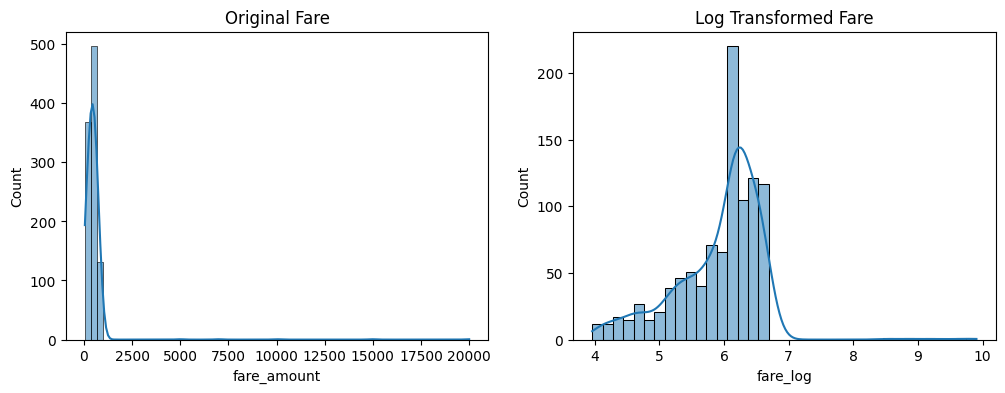

In [179]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(trips["fare_amount"], kde=True, ax=axes[0])
axes[0].set_title("Original Fare")

sns.histplot(trips["fare_log"], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Fare")

plt.show()

## RIDERS Dataset Transformation

#### 1. Label Encoding

In [180]:
le = LabelEncoder()
riders["gender_encoded"] = le.fit_transform(riders["gender"])

#### 2. Binning

In [181]:
riders["ride_frequency"] = pd.cut(
    riders["total_rides"],
    bins=3,
    labels=["Low","Medium","High"]
)

In [182]:
riders["ride_frequency"]

0      Low
1      Low
2      Low
3      Low
4      Low
      ... 
995    Low
996    Low
997    Low
998    Low
999    Low
Name: ride_frequency, Length: 1000, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

### Ride Frequency Distribution

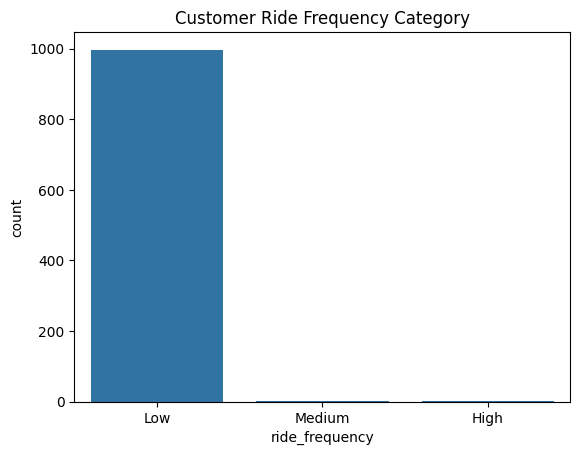

In [183]:
sns.countplot(x="ride_frequency", data=riders)
plt.title("Customer Ride Frequency Category")
plt.show()

In [184]:
zones = pd.get_dummies(zones, columns=["zone_name"], drop_first=True)

In [185]:
print("Trips Shape:", trips.shape)
print("Riders Shape:", riders.shape)
print("Zones Shape:", zones.shape)

Trips Shape: (1000, 19)
Riders Shape: (1000, 13)
Zones Shape: (1000, 8)


#  Part-5 Feature Scaling

## Trips Dataset FS

In [186]:
trips_numeric = trips[["distance_km","duration_min","fare_amount"]]

#### Apply StandardScale

In [187]:
scaler_std = StandardScaler()

trips_std_scaled = pd.DataFrame(
    scaler_std.fit_transform(trips_numeric),
    columns=trips_numeric.columns
)

#### Before vs After Statistics

In [188]:
before_stats = trips_numeric.describe().loc[["mean","std","min","max"]]
after_stats_std = trips_std_scaled.describe().loc[["mean","std","min","max"]]

print("Before Scaling\n")
print(before_stats)

print("\nAfter Standard Scaling\n")
print(after_stats_std)

Before Scaling

      distance_km  duration_min   fare_amount
mean    14.997030      51.22300    484.581079
std     31.846461      67.65069    888.329611
min      1.120000       5.00000     51.490000
max    800.000000    1500.00000  20000.000000

After Standard Scaling

       distance_km  duration_min   fare_amount
mean  1.598721e-17  1.776357e-17  1.243450e-17
std   1.000500e+00  1.000500e+00  1.000500e+00
min  -4.359660e-01 -6.836017e-01 -4.877782e-01
max   2.466195e+01  2.142627e+01  2.197966e+01


#### Apply MinMaxScaler

In [189]:
scaler_mm = MinMaxScaler()

trips_mm_scaled = pd.DataFrame(
    scaler_mm.fit_transform(trips_numeric),
    columns=trips_numeric.columns
)

#### Before vs After Statistics

In [190]:
after_stats_mm = trips_mm_scaled.describe().loc[["mean","std","min","max"]]

print("\nAfter MinMax Scaling\n")
print(after_stats_mm)


After MinMax Scaling

      distance_km  duration_min  fare_amount
mean     0.017371      0.030918     0.021710
std      0.039864      0.045251     0.044531
min      0.000000      0.000000     0.000000
max      1.000000      1.000000     1.000000


### Riders Dataset FS

In [191]:
riders_numeric = riders[["age","total_rides","cancelled_rides","avg_rating"]]

#### Apply StandardScale

In [192]:
riders_std = pd.DataFrame(
    StandardScaler().fit_transform(riders_numeric),
    columns=riders_numeric.columns
)

print("Riders Before\n", riders_numeric.describe().loc[["mean","std","min","max"]])
print("\nRiders After StandardScaler\n", riders_std.describe().loc[["mean","std","min","max"]])

Riders Before
              age  total_rides  cancelled_rides  avg_rating
mean   39.441208    259.99100        24.770186    3.736042
std    15.804440    236.03478        13.953626    0.749072
min     5.000000      1.00000         0.000000    0.500000
max   300.000000   5000.00000        49.000000    9.000000

Riders After StandardScaler
                age   total_rides  cancelled_rides    avg_rating
mean -1.119105e-16  7.105427e-17    -1.474376e-16  2.788880e-16
std   1.000500e+00  1.000500e+00     1.000500e+00  1.000500e+00
min  -2.180301e+00 -1.097807e+00    -1.776067e+00 -4.322228e+00
max   1.649468e+01  2.009187e+01     1.737322e+00  7.030819e+00


#### Apply MinMaxScale

In [193]:
riders_mm = pd.DataFrame(
    MinMaxScaler().fit_transform(riders_numeric),
    columns=riders_numeric.columns
)

print("\nRiders After MinMaxScaler\n", riders_mm.describe().loc[["mean","std","min","max"]])


Riders After MinMaxScaler
            age  total_rides  cancelled_rides  avg_rating
mean  0.116750     0.051809         0.505514    0.380711
std   0.053574     0.047216         0.284768    0.088126
min   0.000000     0.000000         0.000000    0.000000
max   1.000000     1.000000         1.000000    1.000000


In [194]:
zones_numeric = zones[["population_density","traffic_index","avg_speed_kmph"]]

In [195]:
zones_std = pd.DataFrame(
    StandardScaler().fit_transform(zones_numeric),
    columns=zones_numeric.columns
)

print("Zones After StandardScaler\n", zones_std.describe().loc[["mean","std","min","max"]])

Zones After StandardScaler
       population_density  traffic_index  avg_speed_kmph
mean       -5.329071e-18  -7.238654e-17   -3.197442e-17
std         1.000500e+00   1.000500e+00    1.000500e+00
min        -1.843057e-01  -1.427527e+00   -1.603891e+00
max         2.521869e+01   1.370063e+01    1.234100e+01


In [196]:
zones_mm = pd.DataFrame(
    MinMaxScaler().fit_transform(zones_numeric),
    columns=zones_numeric.columns
)

print("\nZones After MinMaxScaler\n", zones_mm.describe().loc[["mean","std","min","max"]])


Zones After MinMaxScaler
       population_density  traffic_index  avg_speed_kmph
mean            0.007255       0.094362        0.115016
std             0.039385       0.066135        0.071747
min             0.000000       0.000000        0.000000
max             1.000000       1.000000        1.000000


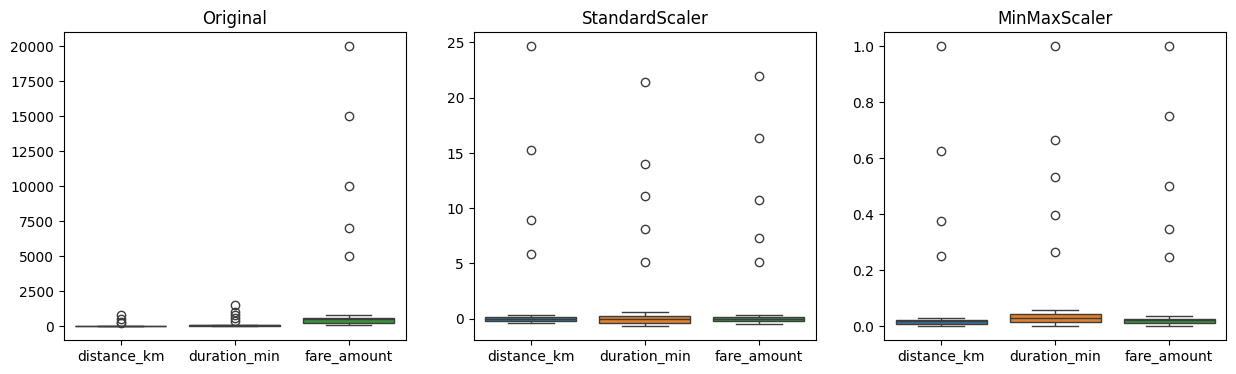

In [197]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.boxplot(data=trips_numeric, ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(data=trips_std_scaled, ax=axes[1])
axes[1].set_title("StandardScaler")

sns.boxplot(data=trips_mm_scaled, ax=axes[2])
axes[2].set_title("MinMaxScaler")

plt.show()

# Part-6 Feature Construction

In [198]:
import pandas as pd
import numpy as np

# Merge on rider_id
data = trips.merge(riders, on="rider_id", how="left")

data.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_z,distance_z,...,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,total_rides_z,cancelled_rides_z,gender_encoded,ride_frequency
0,1.0,103.0,Central,22.48,45.0,517.74,2023-05-12 00:40:00,0.0,0.037346,0.235088,...,Male,Mumbai,2024-02-08,160.0,26.0,4.45,-0.423840,0.088180,1,Low
1,2.0,436.0,Central,14.14,43.0,536.38,2023-03-12 02:43:00,0.0,0.058340,-0.026925,...,Female,Kolkata,2021-01-09,481.0,3.0,3.97,0.936809,-1.560962,0,Low
2,3.0,861.0,North,20.62,17.0,250.55,2023-04-29 23:49:00,0.0,-0.263583,0.176653,...,Male,Chennai,2021-02-01,495.0,14.0,4.01,0.996152,-0.772242,1,Low
3,4.0,271.0,North,11.86,68.0,61.33,2023-01-22 21:51:00,1.0,-0.476696,-0.098554,...,Male,Chennai,2023-12-25,185.0,25.0,4.25,-0.317871,0.016478,1,Low
4,5.0,107.0,South,16.45,15.0,773.76,2023-03-04 08:53:00,1.0,0.325694,0.045647,...,Male,Bangalore,2021-10-07,241.0,9.0,2.65,-0.080499,-1.130751,1,Low


### 1 Avg Ride Distance & Fare

In [199]:
data["avg_ride_distance"] = np.where(
    data["total_rides"] != 0,
    data["distance_km"] / data["total_rides"],
    0
)

### 2 avg_ride_fare

In [200]:
data["avg_ride_fare"] = np.where(
    data["total_rides"] != 0,
    data["fare_amount"] / data["total_rides"],
    0
)

### 3 Peak Hour Flag

In [201]:
data["ride_date"] = pd.to_datetime(data["ride_date"])

data["hour"] = data["ride_date"].dt.hour

data["is_peak_hour"] = np.where(
    ((data["hour"] >= 7) & (data["hour"] <= 9)) |
    ((data["hour"] >= 18) & (data["hour"] <= 21)),
    1, 0
)

### 4 Days Since Signup

In [202]:
data["signup_date"] = pd.to_datetime(data["signup_date"])

data["days_since_signup"] = (
    pd.Timestamp.today() - data["signup_date"]
).dt.days

### 5 Surge Flag

In [203]:
data["fare_per_km"] = np.where(
    data["distance_km"] != 0,
    data["fare_amount"] / data["distance_km"],
    0
)

threshold = 20   # change if needed

data["surge_flag_new"] = np.where(
    data["fare_per_km"] > threshold,
    1, 0
)

In [207]:
data[[
    "avg_ride_distance",
    "avg_ride_fare",
    "is_peak_hour",
    "days_since_signup",
    "fare_per_km",
    "surge_flag_new"
]].head()

,avg_ride_distance,avg_ride_fare,is_peak_hour,days_since_signup,fare_per_km,surge_flag_new
0,0.140500,3.235875,0,746,23.031139,1
1,0.029397,1.115135,0,1871,37.933522,1
2,0.041657,0.506162,0,1848,12.150824,0
3,0.064108,0.331514,1,791,5.171164,0
4,0.068257,3.210622,1,1600,47.037082,1


# Part-7 Final Dataset

In [205]:
print(trips.columns)
print(zones.columns)

Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'ride_date', 'surge_flag', 'fare_z', 'distance_z',
       'fare_winsorized', 'hour', 'day_of_week', 'month', 'payment_mode_Cash',
       'payment_mode_UPI', 'fare_log', 'distance_log', 'duration_sqrt'],
      dtype='str')
Index(['population_density', 'traffic_index', 'avg_speed_kmph', 'zone_type',
       'zone_name_East', 'zone_name_North', 'zone_name_South',
       'zone_name_West'],
      dtype='str')
